In [ ]:
%matplotlib inline
from tiingo import TiingoClient as client
import pandas as pd
import backtrader as bt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


client = client({'api_key': '5fc020666c7e26bf87f6f33578322e28dd6e8e49' })
df = client.get_dataframe('TLT', startDate="1-1-2024", endDate="5-28-25",)
df.to_csv('TLT_tiingo_data.csv')
df.head()

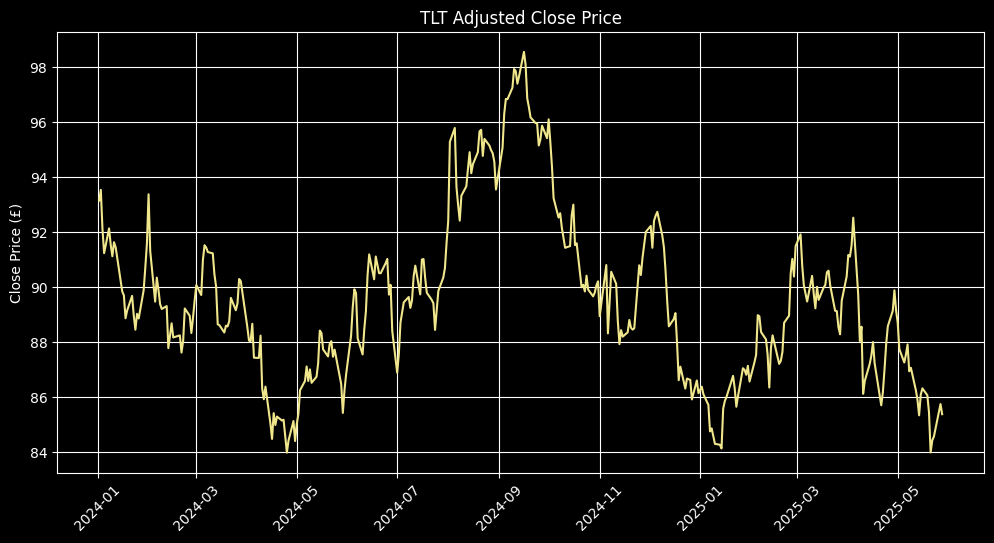

In [88]:
df = pd.read_csv('TLT_tiingo_data.csv', parse_dates=['date'])

plt.figure(figsize=(10, 5))
plt.grid()
plt.tight_layout()
plt.style.use('dark_background')
plt.plot(df['date'], df['adjClose'], color='khaki')
plt.ylabel('Close Price (£)')
plt.title('TLT Adjusted Close Price')


plt.xticks(rotation=45)

plt.show()

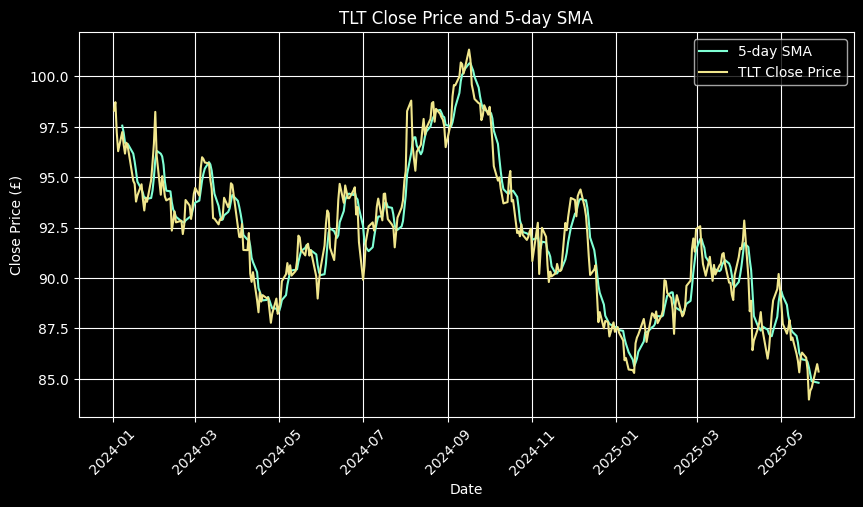

In [89]:
df = pd.read_csv('TLT_tiingo_data.csv', parse_dates=['date']) #Read the saved .csv file
df["SMA5"] = df["close"].rolling(window=5).mean()     #Define SMA4 as the mean of 4 consecutive close prices



plt.figure(figsize = (10,5))
plt.plot(df.date, df['SMA5'], label=("5-day SMA"), linewidth=1.5, color = 'aquamarine')        #Plot of 4-day mean alongside close price versus time
plt.plot(df.date, df['close'], label="TLT Close Price", linewidth=1.5, color='khaki')
plt.ylabel('Close Price (£)')
plt.xlabel('Date')
plt.grid()
plt.legend()
plt.title('TLT Close Price and 5-day SMA')
  # Monthly tick locator
  


plt.xticks(rotation=45)
plt.show()


In [90]:
df.dropna
class PandasData(bt.feeds.PandasData):
    params = (
        ('datetime', 'date'),
        ('open', 'open'),
        ('high', 'high'),
        ('low', 'low'),
        ('close', 'close'),
        ('volume', 'volume'),
        
    )

class SMA_crossover(bt.Strategy):
    def __init__(self):
        self.sma = bt.indicators.SimpleMovingAverage(self.data.close, period=5)  # 5-day SMA
    def next(self):
        value = self.broker.getvalue()  # Get the current value of the portfolio
        price = self.data.close[0]  # Get the current price of the asset
        size = int((0.1)*value / price)  # Calculate the number of shares to buy based on the portfolio value
        if self.data.close[0] < (0.997)*self.sma[0]: # Check if the current price is below 0.997 times the SMA
            if not self.position: 
                    self.buy(size=size)   #Buy a volume worth 10% of the portfolio                             
        elif self.data.close[0] > (1.003)*self.sma[0]: # Check if the current price is above 1.003 times the SMA
            if self.position:
                    self.sell(size=size) # Sell the same volume worth 10% of the portfolio
                    

            
    
                


In [91]:
cerebro = bt.Cerebro() #Cerebro Class gathers inputs and analysers
data = PandasData(dataname=df)
cerebro.addstrategy(SMA_crossover)   #Adding my strategy into Cerebro
bt.feeds.PandasData(dataname=df)
cerebro.adddata(data)

# Add analyzers
cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe')
cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')
cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')
cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades')

# Set initial cash
cerebro.broker.setcash(10000.0)
print('Initial Portfolio Value: %.2f' % cerebro.broker.getvalue())

# Run backtest
results = cerebro.run()

# Plot result
cerebro.plot(figsize=(20 , 5), style='candlestick', volume=False, barup='green', bardown='red')
strat = results[0]

print("Sharpe Ratio:", strat.analyzers.sharpe.get_analysis())
print("Drawdown:", strat.analyzers.drawdown.get_analysis())
print("Returns:", strat.analyzers.returns.get_analysis())
print("Trade Analysis:", strat.analyzers.trades.get_analysis())

Initial Portfolio Value: 10000.00


<IPython.core.display.Javascript object>

AttributeError: 'RRuleLocator' object has no attribute 'set_view_interval'

In [ ]:
strat = results[0]
print('Final Portfolio Value: %.2f' % cerebro.broker.getvalue())
cerebro.plot(figsize=(30, 6))
plt.figure(figsize=(30, 6))
plt.tight_layout()
plt.legend(loc='upper left')
plt.grid()
plt.show()
performance = cerebro.plot(style='candlestick', iplot=False, width=30, volume=False)
plt.savefig('TLT_backtest_plot.png')





Final Portfolio Value: 12449.08


<IPython.core.display.Javascript object>

AttributeError: 'RRuleLocator' object has no attribute 'set_view_interval'